<a href="https://colab.research.google.com/github/Kanishk-Pathania/CODING-SAMURAI-INTERNSHIP-TASK/blob/main/AIR_INDIA_CRASH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install transformers datasets scikit-learn

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

# Load your Excel dataset
df = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/Air_India_Crash_Comments_with_Sentiments-Semi Supervised.xlsx")

# Optional: Keep only relevant columns
df = df[["sentiment"]].dropna()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.semi_supervised import LabelSpreading
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# 1. Load the Excel file
df = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/Air_India_Crash_Comments_with_Sentiments-Semi Supervised.xlsx")

# 2. Prepare the data
df["content"] = df["content"].astype(str)
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X = vectorizer.fit_transform(df["content"])

# 3. Map sentiment labels
label_map = {"positive": 0, "negative": 1, "neutral": 2}
reverse_map = {v: k for k, v in label_map.items()}
y = df["sentiment"].map(label_map)

# 4. Prepare the semi-supervised label array
y_semi = y.copy()
y_semi[df["sentiment"].isna()] = -1  # Unlabeled data is -1

# 5. Label Spreading model
label_model = LabelSpreading(kernel='knn', n_neighbors=5, alpha=0.2)
label_model.fit(X, y_semi)

# 6. Predict for all data (transduction_ gives labels for all)
df["predicted_sentiment"] = [reverse_map[i] for i in label_model.transduction_]

# 7. Fill missing labels
df["final_sentiment"] = df["sentiment"].fillna(df["predicted_sentiment"])

# 8. Vectorize again (optional but safer for clean separation)
X_final = vectorizer.transform(df["content"])
y_final = df["final_sentiment"]

# 9. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=2290, random_state=92)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

    negative       0.77      0.67      0.71       685
     neutral       0.81      0.91      0.86      2286
    positive       0.75      0.54      0.63       622

    accuracy                           0.80      3593
   macro avg       0.78      0.70      0.73      3593
weighted avg       0.79      0.80      0.79      3593



In [ ]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# Encode labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Train XGBoost classifier
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)
xgb_model.fit(X_train, y_train_encoded)

# Predict and decode labels
y_pred_encoded = xgb_model.predict(X_test)
y_pred = label_encoder.inverse_transform(y_pred_encoded)

# Print classification report
print(classification_report(y_test, y_pred))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:11:25] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

    negative       0.75      0.56      0.64       685
     neutral       0.76      0.92      0.83      2286
    positive       0.75      0.39      0.51       622

    accuracy                           0.76      3593
   macro avg       0.75      0.62      0.66      3593
weighted avg       0.76      0.76      0.74      3593



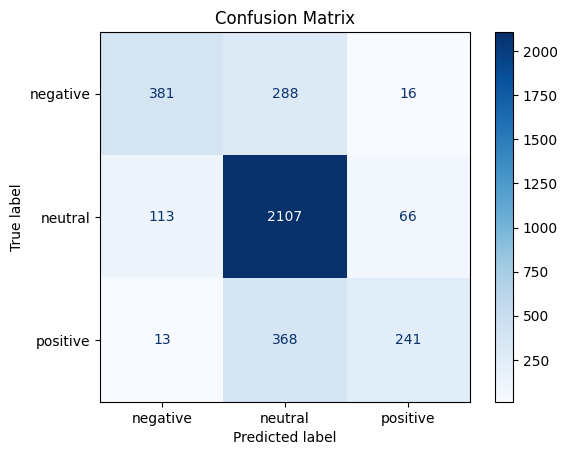

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


sentiment
neutral     9312
negative    3214
positive    2860
Name: count, dtype: int64


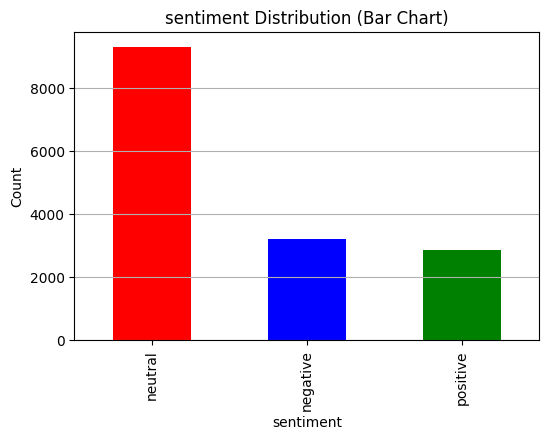

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Check the sentiment column
print(df['sentiment'].value_counts())

# ----- Bar Chart -----
plt.figure(figsize=(6,4))
df['sentiment'].value_counts().plot(kind='bar', color=['red', 'blue', 'green'])
plt.title("sentiment Distribution (Bar Chart)")
plt.xlabel("sentiment")
plt.ylabel("Count")
plt.grid(axis='y')
plt.show()

In [ ]:
import joblib

joblib.dump(label_model, r"C:\Users\DELL\OneDrive\Desktop\semi_supervised_sentiment_model.pkl")
#print("Model saved successfully at Desktop.")


['C:\\Users\\DELL\\OneDrive\\Desktop\\semi_supervised_sentiment_model.pkl']